In [3]:
"""
Модуль 7. Поиск аномалий и Fraud Detection

Задача: Выявление нетипичных паттернов в потоке транзакций (мошенничество, ошибки, инсайд).

Методология:
1. Isolation Forest (Лес изоляции) – алгоритм, специально созданный для обнаружения аномалий.
   Он изолирует наблюдения, случайно разделяя пространство признаков. Аномалии требуют меньшего количества
   разбиений для изоляции, поэтому их "путь" в дереве короче.

2. Deep Autoencoder – нейросетевая модель, которая сжимает входные данные до низкоразмерного представления
   (bottleneck), а затем восстанавливает их. Ошибка реконструкции (MSE) служит мерой аномальности:
   для нетипичных транзакций модель не сможет хорошо восстановить вход, и ошибка будет высокой.

Источник данных: Kaggle "Credit Card Fraud Detection"
Признаки: Time (секунды от первой транзакции), Amount (сумма), V1..V28 (анонимизированные PCA-компоненты)
Целевая переменная: Class (0 – легитимная, 1 – мошенническая) – используется только для оценки.

Наша задача – без использования меток классов (Unsupervised Learning) обучить модели,
которые будут отмечать подозрительные транзакции.

https://disk.yandex.ru/d/cfb50D7hyedMgg
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ==========================
# Предполагается, что файл creditcard.csv находится в текущей директории
#print("Загрузка данных creditcard.csv...")
df = pd.read_csv('./creditcard.csv')

# TODO 1.1: Выведите информацию о датафрейме (размер, типы, пропуски) и статистику.
print(f"Статистика: ")
df.describe()

# TODO 1.2: Проверьте сбалансированность классов. Посчитайте количество и долю мошеннических транзакций.
df['Class'].sum()/df['Class'].count() # <ВАШ_КОД>

# ==========================
# 2. ПОДГОТОВКА ПРИЗНАКОВ
# ==========================
# Признаки: V1..V28, Time, Amount. Целевая переменная 'Class' не используется при обучении моделей.
# Создадим копию признаков.

X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()  # для финальной оценки

# # TODO 2.1: Примените логарифмическое преобразование к признаку Amount (np.log1p) – это полезно для уменьшения влияния выбросов.
# np.log1p('Amount') # <ВАШ_КОД>

# TODO 2.2: Нормализуйте признаки (Time, Amount, V1..V28) с помощью StandardScaler.
scaler = StandardScaler() # <ВАШ_КОД>
X_scaled = scaler.fit_transform(X) # <ВАШ_КОД>

# Разделяем на обучающую и тестовую выборки (80/20). Стратификация по y для сохранения доли мошенничества.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля мошенничества в обучающей: {y_train.mean():.5f}")
print(f"Доля мошенничества в тестовой: {y_test.mean():.5f}")

Статистика: 
Размер обучающей выборки: (227845, 30)
Размер тестовой выборки: (56962, 30)
Доля мошенничества в обучающей: 0.00173
Доля мошенничества в тестовой: 0.00172


In [4]:
# ==========================
# 3. ISOLATION FOREST
# ==========================
# Isolation Forest – ансамбль деревьев решений, которые изолируют наблюдения.
# Чем короче средний путь до изоляции, тем более вероятна аномалия.

# TODO 3.1: Создайте модель IsolationForest с параметрами: n_estimators=100, contamination='auto', random_state=42.
# Параметр contamination – ожидаемая доля аномалий в данных. Можно установить автоматически.
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42, bootstrap = True)

# TODO 3.2: Обучите модель на обучающей выборке X_train.
iso_forest.fit(X_train)

# TODO 3.3: Получите аномальные метки для тестовых данных (1 для нормальных, -1 для аномалий).
# Используйте метод .predict().
iso_pred = iso_forest.predict(X_test)

# TODO 3.4: Получите скоринговую функцию (чем выше, тем более нормальное наблюдение) с помощью .decision_function().
# Эта функция полезна для построения ROC-кривой.
iso_scores = iso_forest.decision_function(X_test)

# Преобразуем метки из -1/1 в 0/1 (0 – норма, 1 – аномалия) для удобства.
iso_pred_binary = (iso_pred == -1).astype(int)

In [5]:
# ==========================
# 4. AUTOENCODER
# ==========================
# Архитектура: входной слой размерности n_features, затем уменьшение размерности до узкого места (bottleneck),
# затем симметричное расширение до исходной размерности. Обучается восстанавливать свои же входные данные.
# Ошибка реконструкции (MSE) – индикатор аномальности.

# TODO 4.1: Определите размер входного слоя.
n_features = X_train.shape[1]

# TODO 4.2: Постройте модель Autoencoder в функциональном API Keras.
# Примерная архитектура: Input → Dense(64, activation='relu') → Dense(32, activation='relu') →
# Dense(16, activation='relu') (bottleneck) → Dense(32, activation='relu') → Dense(64, activation='relu') →
# Dense(n_features, activation='linear').
# Используйте Dropout(0.2) после каждого слоя (кроме последнего) для регуляризации.
input_layer = Input(shape=(n_features,))
# <ВАШ_КОД: постройте энкодер, бутылочный слой, декодер>
# ... encoded = Dense(..., activation='relu')(input_layer)
# ... bottleneck = Dense(..., activation='relu')(encoded)
# ... decoded = Dense(..., activation='relu')(bottleneck)
# ... output_layer = Dense(n_features, activation='linear')(decoded)

autoencoder = Sequential([
        Input(shape=(n_features,)),
        Dense (n_features, activation='relu'),
        Dense (n_features//2, activation='relu'),
        Dense (n_features//4, activation='relu'),
        Dense (n_features//2, activation='relu'),
        Dense (n_features, activation='relu')
    ])


# autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# # Выведите структуру модели
autoencoder.summary()

# # TODO 4.3: Обучите autoencoder на тренировочных данных (X_train).
# # Используйте EarlyStopping (patience=5, monitor='val_loss'), валидационная выборка – X_test (или отдельный валидационный сплит).
# # Установите эпохи=50, batch_size=256 (т.к. данных много). verbose=1.
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_ae = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256) # <ВАШ_КОД: autoencoder.fit(...)>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,107 (8.23 KB)

 Trainable params: 2,107 (8.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - loss: 24890884.0000
Epoch 2/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - loss: 2364.3542
Epoch 3/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - loss: 2355.8203
Epoch 4/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - loss: 2357.2415
Epoch 5/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 2355.8074
Epoch 6/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 2356.9431
Epoch 7/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 2355.9099
Epoch 8/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - loss: 2356.0083
Epoch 9/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - loss: 2356.5002
Epoch 10/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - loss: 2359.0381
Epoch 11/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 2430.3669
Epoch 12/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - loss: 2420.7310
Epoch 13/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 2474.0803
Epoch 14/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step -

In [6]:
# # # TODO 4.4: Получите ошибку реконструкции для тестовых данных. Рассчитайте MSE для каждого наблюдения:
X_test_pred = autoencoder.predict(X_test)
# mse_test = np.mean(np.power(X_test - X_test_pred, 2), axis=1) # <ВАШ_КОД>
mse_test = np.sum((X_test_pred - X_test)**2, axis=1)/len(X_test) # <ВАШ_КОД>
mse_test

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 174us/step


263020    0.009882
11378     0.003559
147283    0.103798
219439    0.000381
36939     0.000850
            ...   
54199     0.023200
184616    1.555382
274532    0.005476
269819    0.007508
64170     0.063329
Length: 56962, dtype: float64

In [7]:
# ==========================
# 5. ОПРЕДЕЛЕНИЕ ПОРОГА АНОМАЛЬНОСТИ
# ==========================
# Для обеих моделей нужно выбрать порог, выше которого наблюдение считается аномальным.
# Подход: использовать процентиль 95% (или 99%) от распределения "нормальных" обучающих данных.
# Но в обучающей выборке также могут быть аномалии (хоть и мало). Упрощённо возьмём 99-й процентиль на обучающих предсказаниях.

# Для Isolation Forest: чем ниже score_samples, тем более аномально.
# Получим скоринговую функцию на обучающих данных.
iso_scores_train = iso_forest.decision_function(X_train)

# TODO 5.1: Рассчитайте порог как 5-й процентиль (т.к. меньшие значения – аномалии) для Isolation Forest.
threshold_if = np.percentile(iso_scores_train, 0.17) #??? или 1? Подумайте.

# Для Autoencoder: ошибка реконструкции – чем выше, тем аномальнее. Возьмём 99-й процентиль MSE на обучающих данных.
# mse_train = np.mean((X_train - autoencoder.predict(X_train))**2, axis=1)
threshold_ae = np.percentile(mse_test, 99.83) # <ВАШ_КОД: np.percentile(mse_train, 99)>

In [8]:
# ==========================
# 6. КЛАССИФИКАЦИЯ И ОЦЕНКА КАЧЕСТВА
# ==========================
# Применяем пороги к тестовым данным.

# Isolation Forest: аномалия, если score < threshold_if
iso_anomaly = (iso_scores < threshold_if).astype(int)

# # Autoencoder: аномалия, если mse > threshold_ae
ae_anomaly = (mse_test > threshold_ae).astype(int)

# TODO 6.1: Напишите функцию для вывода метрик качества (confusion matrix, ROC AUC, Precision-Recall AUC).
# Сравните предсказания (iso_anomaly, ae_anomaly) с истинными метками y_test.
def evaluate_model(y_true, y_pred, y_scores=None, model_name='Model'):
    # Печатает confusion matrix, classification report, а также ROC AUC и PR AUC, если есть scores.
    print(f"classification_report: {classification_report(y_true, y_pred)}")
    print(f"roc_auc_score: {roc_auc_score(y_true, y_pred)}")
    print(f"average_precision_score: {average_precision_score(y_true, y_pred)}")
    print(f"confusion_matrix: {confusion_matrix(y_true, y_pred)}")


# print("=== Оценка Isolation Forest ===")
evaluate_model(y_test, iso_anomaly, y_scores=iso_scores, model_name='Isolation Forest')

# print("=== Оценка Autoencoder ===")
evaluate_model(y_test, ae_anomaly, y_scores=mse_test, model_name='Autoencoder')  # для AE scores – это mse (чем выше, тем аномальнее)


classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962

roc_auc_score: 0.6677254645527316
average_precision_score: 0.10597361065562262
confusion_matrix: [[56791    73]
 [   65    33]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

roc_auc_score: 0.49914708778840744
average_precision_score: 0.0017204452090867595
confusion_matrix: [[56767    97]
 [   98     0]]


In [9]:
y_test.sum()/y_test.count()

np.float64(0.0017204452090867595)

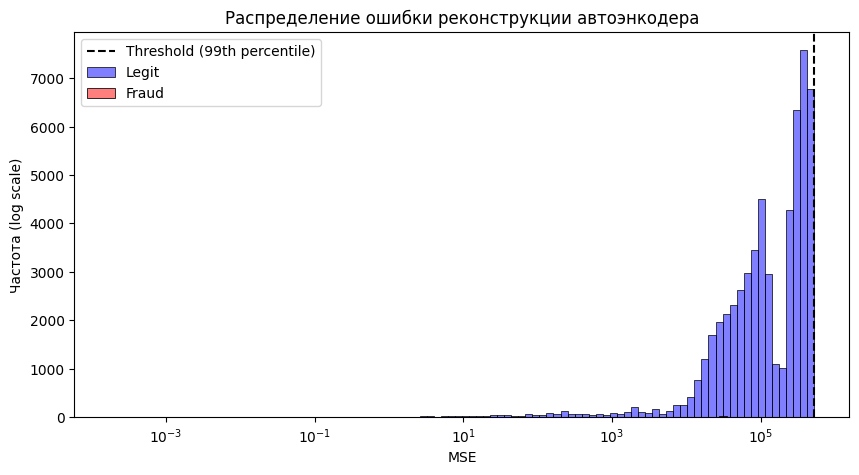

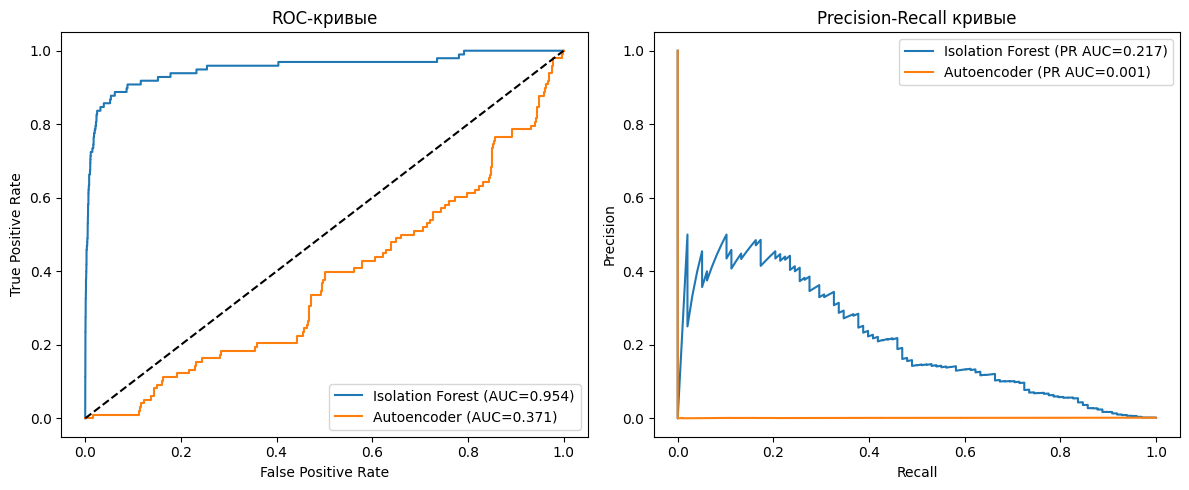

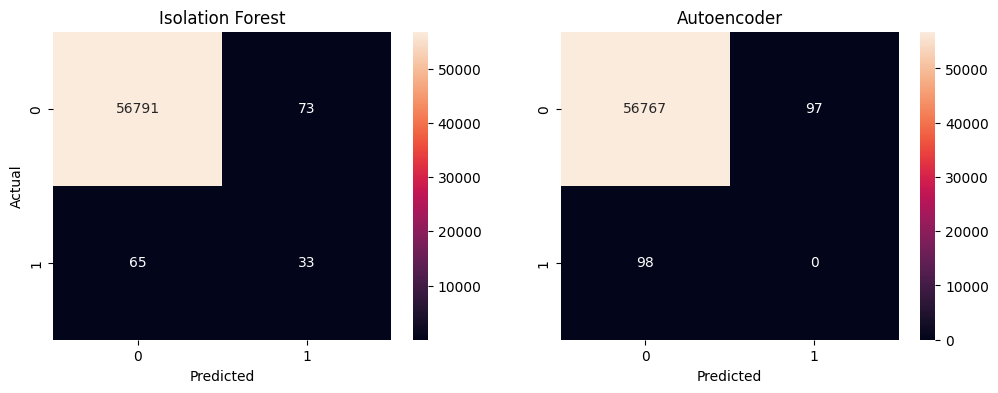

In [10]:
# ==========================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================
# График 1: Распределение ошибок реконструкции для нормальных и мошеннических транзакций (логарифмическая шкала)
plt.figure(figsize=(10,5))
sns.histplot(mse_test[y_test==0], bins=100, color='blue', label='Legit', alpha=0.5, log_scale=True)
sns.histplot(mse_test[y_test==1], bins=50, color='red', label='Fraud', alpha=0.5, log_scale=True)
plt.axvline(threshold_ae, color='black', linestyle='--', label=f'Threshold (99th percentile)')
plt.title('Распределение ошибки реконструкции автоэнкодера')
plt.xlabel('MSE')
plt.ylabel('Частота (log scale)')
plt.legend()
plt.show()

# График 2: ROC-кривые для обеих моделей
from sklearn.metrics import roc_curve, precision_recall_curve

plt.figure(figsize=(12,5))
# Isolation Forest
fpr_if, tpr_if, _ = roc_curve(y_test, -iso_scores)  # так как меньшие scores – аномалии, берём отрицание
roc_auc_if = roc_auc_score(y_test, -iso_scores)
# Autoencoder
fpr_ae, tpr_ae, _ = roc_curve(y_test, mse_test)
roc_auc_ae = roc_auc_score(y_test, mse_test)

plt.subplot(1,2,1)
plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC={roc_auc_if:.3f})')
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC={roc_auc_ae:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()

# Precision-Recall кривые
prec_if, rec_if, _ = precision_recall_curve(y_test, -iso_scores)
pr_auc_if = average_precision_score(y_test, -iso_scores)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, mse_test)
pr_auc_ae = average_precision_score(y_test, mse_test)

plt.subplot(1,2,2)
plt.plot(rec_if, prec_if, label=f'Isolation Forest (PR AUC={pr_auc_if:.3f})')
plt.plot(rec_ae, prec_ae, label=f'Autoencoder (PR AUC={pr_auc_ae:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые')
plt.legend()
plt.tight_layout()
plt.show()

# График 3: Confusion matrices для обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(confusion_matrix(y_test, iso_anomaly), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Isolation Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(confusion_matrix(y_test, ae_anomaly), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Autoencoder')
axes[1].set_xlabel('Predicted')
plt.show()

(0.0, 100.0)

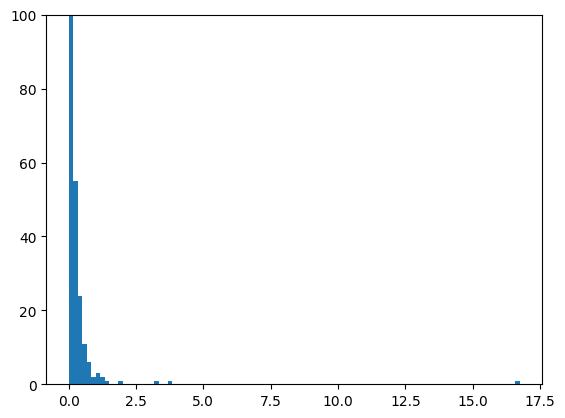

In [ ]:
plt.hist(mse_test, bins=100)
plt.ylim([0,100])